In [45]:


"""
====================================================
 Lending Club Loan Interest Rate Prediction
 Mission: Predict the interest rate assigned to a loan
          applicant based on their financial profile and
          loan characteristics — helping lenders make
          data-driven, fair pricing decisions and helping
          borrowers understand what drives their rate.

 Dataset: Lending Club Loan Data
 Source:  Kaggle — https://www.kaggle.com/datasets/wordsforthewise/lending-club
 File:    loan.csv
 License: CC0 Public Domain
====================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import joblib

sns.set(style='whitegrid')

# ============================================================
# 1. LOAD DATA
# ============================================================
file_path = '/content/sample_data/loan.csv'
loan_df = pd.read_csv(file_path, nrows=50000)   # 50k rows for RAM stability

print("=== Dataset Shape ===")
print(loan_df.shape)
print("\n=== First 5 Rows ===")
print(loan_df.head())
print("\n=== Missing Value Counts ===")
print(loan_df.isnull().sum().sort_values(ascending=False).head(20))

=== Dataset Shape ===
(50000, 145)

=== First 5 Rows ===
   id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0 NaN        NaN       2500         2500             2500   36 months   
1 NaN        NaN      30000        30000            30000   60 months   
2 NaN        NaN       5000         5000             5000   36 months   
3 NaN        NaN       4000         4000             4000   36 months   
4 NaN        NaN      30000        30000            30000   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.56        84.92     C        C1  ...                            NaN   
1     18.94       777.23     D        D2  ...                            NaN   
2     17.97       180.69     D        D1  ...                            NaN   
3     18.94       146.51     D        D2  ...                            NaN   
4     16.14       731.78     C        C4  ...                            NaN   

  hardship_last_payment

In [46]:
# 2. FEATURE ENGINEERING
# ============================================================

# --- 2a. Define target variable ---
y = loan_df['int_rate']
X = loan_df.drop(columns=['int_rate'])

# --- 2b. Drop leaky columns (data only known AFTER loan is issued) ---
leaky_cols = [
    'funded_amnt', 'funded_amnt_inv', 'issue_d', 'loan_status', 'pymnt_plan',
    'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
    'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d', 'last_credit_pull_d', 'debt_settlement_flag'
]
print("\nDropping leaky post-issuance columns:", leaky_cols)

# --- 2c. Drop high-cardinality / identifier columns ---
identifiers = [
    'id', 'member_id', 'url', 'desc', 'grade',
    'emp_title', 'title', 'zip_code', 'addr_state', 'earliest_cr_line'
]
print("Dropping identifier / high-cardinality columns:", identifiers)

X = X.drop(columns=leaky_cols + identifiers, errors='ignore')

# --- 2d. Drop columns with >30% missing values ---
missing_pct = X.isnull().sum() / len(X)
cols_to_drop = missing_pct[missing_pct >= 0.3].index.tolist()
print(f"\nDropping {len(cols_to_drop)} columns with >30% missing values:", cols_to_drop)
X = X.loc[:, missing_pct < 0.3]

# --- 2e. Convert text-encoded numerics ---
# 'term'       : " 36 months" → 36
# 'emp_length' : "10+ years"  → 10
if 'term' in X.columns:
    X['term'] = X['term'].astype(str).str.extract(r'(\d+)').astype(float)
    print("Converted 'term' to numeric (months)")

if 'emp_length' in X.columns:
    X['emp_length'] = X['emp_length'].astype(str).str.extract(r'(\d+)').astype(float)
    print("Converted 'emp_length' to numeric (years)")

# --- 2f. Label-encode remaining categorical columns ---
le = LabelEncoder()
cat_cols = ['sub_grade', 'home_ownership', 'verification_status', 'purpose', 'application_type']
for col in cat_cols:
    if col in X.columns:
        X[col] = le.fit_transform(X[col].astype(str))
        print(f"Label-encoded: {col}")

# --- 2g. Keep only numeric columns & fill missing with median ---
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# --- 2h. Drop near-zero variance columns (>99% same value) ---
variance_filter = [col for col in X.columns
                   if X[col].value_counts(normalize=True).iloc[0] > 0.99]
print(f"\nDropping near-zero variance columns: {variance_filter}")
X = X.drop(columns=variance_filter)

print(f"\n✅ Final Feature Count: {X.shape[1]}")
print(f"Features retained: {list(X.columns)}")


Dropping leaky post-issuance columns: ['funded_amnt', 'funded_amnt_inv', 'issue_d', 'loan_status', 'pymnt_plan', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'debt_settlement_flag']
Dropping identifier / high-cardinality columns: ['id', 'member_id', 'url', 'desc', 'grade', 'emp_title', 'title', 'zip_code', 'addr_state', 'earliest_cr_line']

Dropping 39 columns with >30% missing values: ['mths_since_last_delinq', 'mths_since_last_record', 'mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 'revol_bal_joint', 'sec_app_earliest_cr_line', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'sec_app_open_act_il', 'sec_app_num_rev_accts', 'sec_app_chargeoff_within_12

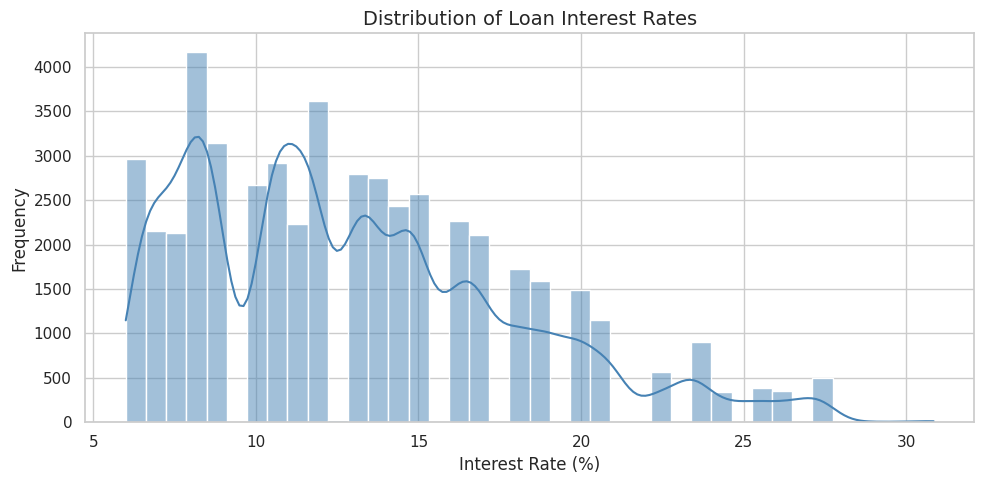

Interpretation: Interest rates are roughly bell-shaped with a slight right skew.
Most loans fall between 8%-20%. High-rate outliers likely reflect riskier borrowers.


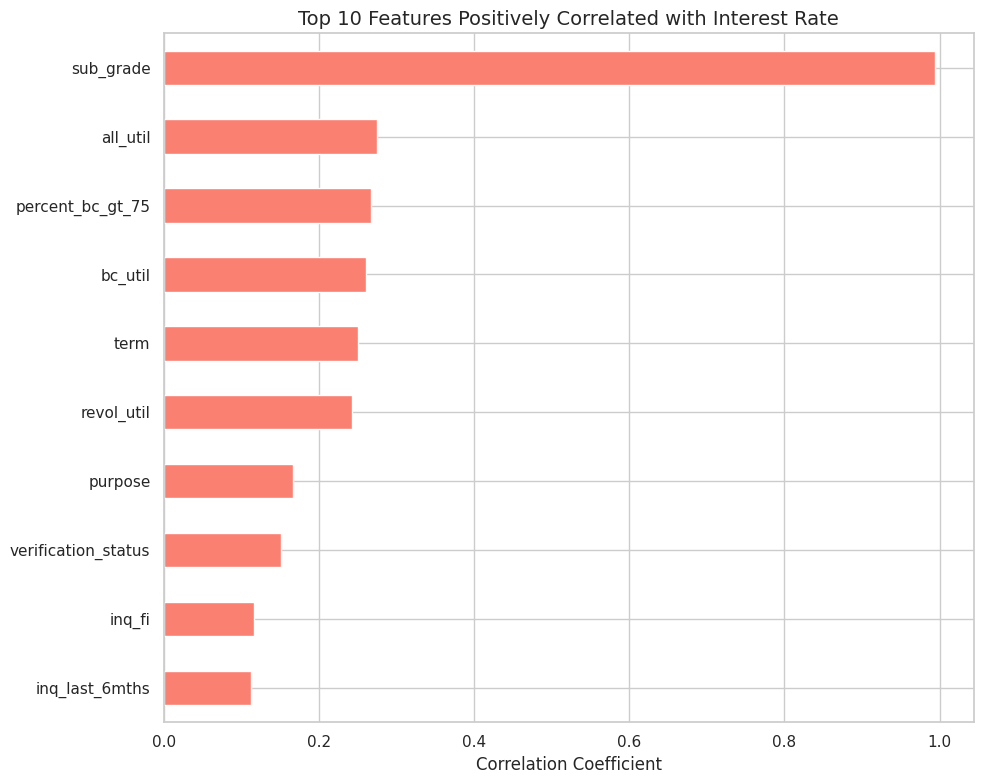

Interpretation: Sub-grade has the highest positive correlation with interest rate,
confirming that Lending Club's internal risk grading is the primary rate driver.


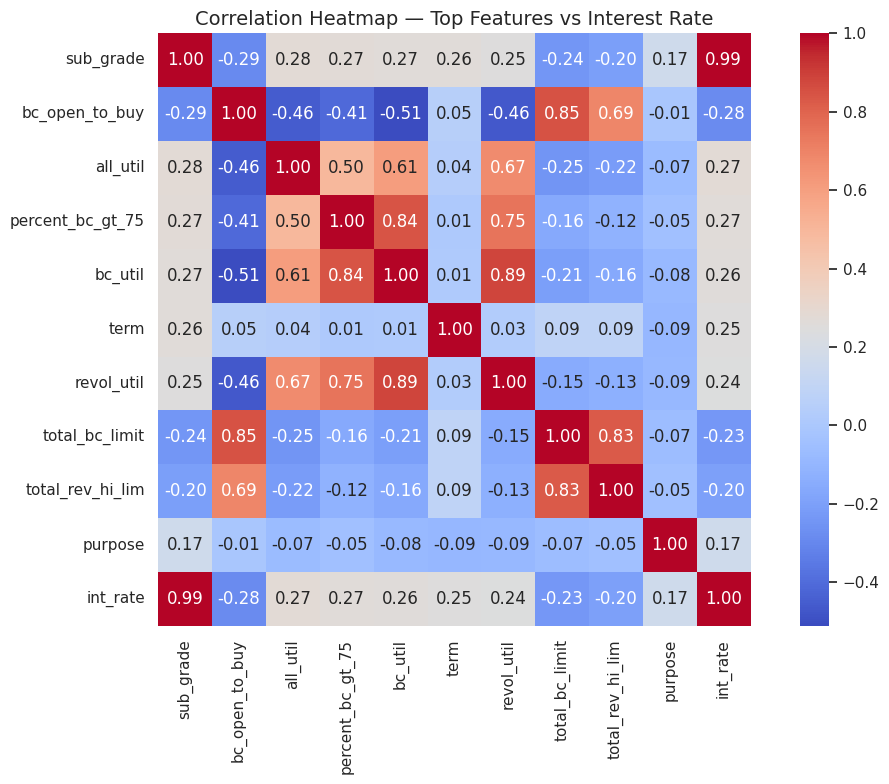

Interpretation: Sub-grade and loan amount are strongly related to interest rate.
Installment amount is highly correlated with loan_amnt (multicollinearity present).


/tmp/ipykernel_1174/738741891.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sub_grade', y='int_rate', data=temp_df, palette='coolwarm')


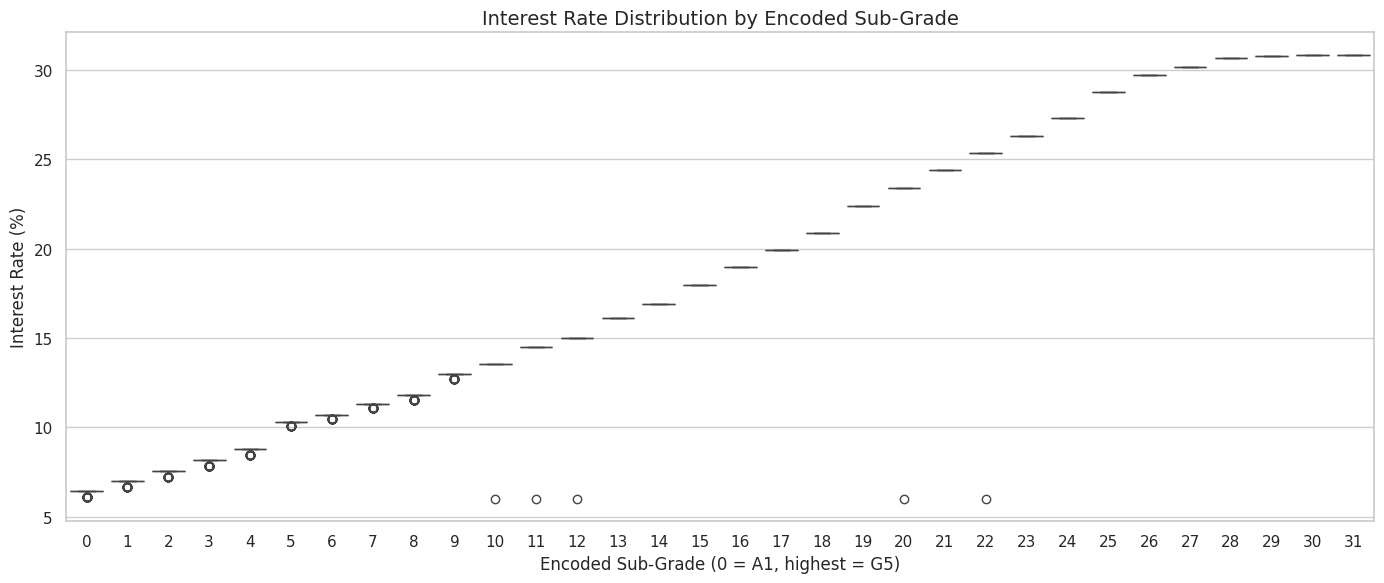

Interpretation: Clear monotonic increase — higher sub-grade encoding = higher rate.
This validates sub_grade as the most predictive feature.


In [47]:
# 3. VISUALIZATIONS
# ============================================================

# --- Viz 1: Distribution of target variable (int_rate) ---
plt.figure(figsize=(10, 5))
sns.histplot(y, kde=True, color='steelblue', bins=40)
plt.title('Distribution of Loan Interest Rates', fontsize=14)
plt.xlabel('Interest Rate (%)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('viz1_interest_rate_distribution.png', dpi=150)
plt.show()
print("Interpretation: Interest rates are roughly bell-shaped with a slight right skew.")
print("Most loans fall between 8%-20%. High-rate outliers likely reflect riskier borrowers.")

# --- Viz 2: Correlation heatmap (top correlated features with int_rate) ---
temp_df = X.copy()
temp_df['int_rate'] = y.values
correlations = temp_df.corr()['int_rate'].drop('int_rate').sort_values()

plt.figure(figsize=(10, 8))
correlations.tail(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Features Positively Correlated with Interest Rate', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.savefig('viz2_top_correlations.png', dpi=150)
plt.show()
print("Interpretation: Sub-grade has the highest positive correlation with interest rate,")
print("confirming that Lending Club's internal risk grading is the primary rate driver.")

# --- Viz 3: Full correlation heatmap (top 10 features) ---
top_features = correlations.abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('int_rate')
plt.figure(figsize=(11, 8))
sns.heatmap(temp_df[top_features].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', square=True)
plt.title('Correlation Heatmap — Top Features vs Interest Rate', fontsize=14)
plt.tight_layout()
plt.savefig('viz3_correlation_heatmap.png', dpi=150)
plt.show()
print("Interpretation: Sub-grade and loan amount are strongly related to interest rate.")
print("Installment amount is highly correlated with loan_amnt (multicollinearity present).")

# --- Viz 4: Sub-grade vs Interest Rate box plot ---
if 'sub_grade' in temp_df.columns:
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='sub_grade', y='int_rate', data=temp_df, palette='coolwarm')
    plt.title('Interest Rate Distribution by Encoded Sub-Grade', fontsize=14)
    plt.xlabel('Encoded Sub-Grade (0 = A1, highest = G5)')
    plt.ylabel('Interest Rate (%)')
    plt.tight_layout()
    plt.savefig('viz4_subgrade_vs_intrate.png', dpi=150)
    plt.show()
    print("Interpretation: Clear monotonic increase — higher sub-grade encoding = higher rate.")
    print("This validates sub_grade as the most predictive feature.")

In [48]:
# 4. TRAIN / TEST SPLIT & STANDARDIZATION
# ============================================================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f"\nTraining set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")
print(f"Mean (train) : {np.mean(X_train):.4f}  ← should be ~0")
print(f"Std  (train) : {np.std(X_train):.4f}   ← should be ~1")



Training set : (40000, 66)
Test set     : (10000, 66)
Mean (train) : 0.0000  ← should be ~0
Std  (train) : 1.0000   ← should be ~1


In [49]:
# 5. MODEL TRAINING
# ============================================================

# --- 5a. Linear Regression via Gradient Descent (SGDRegressor) ---
sgd_reg = SGDRegressor(
    max_iter=1000, tol=1e-3, random_state=42,
    learning_rate='invscaling', eta0=0.01
)

epochs = 100
train_losses, test_losses = [], []

for epoch in range(epochs):
    sgd_reg.partial_fit(X_train, y_train)
    train_losses.append(mean_squared_error(y_train, sgd_reg.predict(X_train)))
    test_losses.append(mean_squared_error(y_test,  sgd_reg.predict(X_test)))

# --- 5b. Decision Tree ---
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_reg.fit(X_train, y_train)

# --- 5c. Random Forest ---
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_reg.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_jobs=-1, random_state=42)

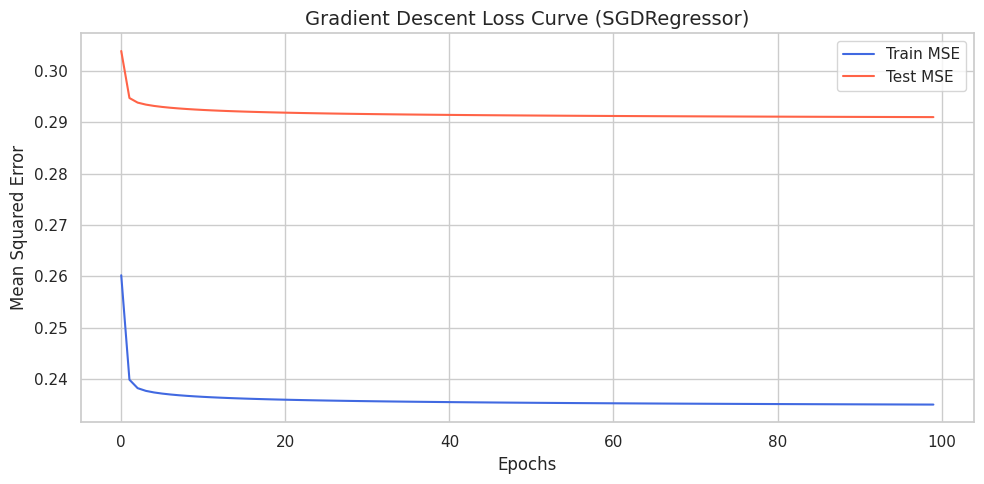

In [50]:
# 6. LOSS CURVE — Train vs Test (SGD)
# ============================================================
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train MSE', color='royalblue')
plt.plot(test_losses,  label='Test MSE',  color='tomato')
plt.title('Gradient Descent Loss Curve (SGDRegressor)', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.tight_layout()
plt.savefig('viz5_loss_curve.png', dpi=150)
plt.show()


In [51]:
# 7. EVALUATION SUMMARY
# ============================================================
print("\n=== Model Evaluation on Test Set ===")
models = {
    'SGD Regressor (Linear)': sgd_reg,
    'Decision Tree'          : dt_reg,
    'Random Forest'          : rf_reg,
}
results = {}
for name, model in models.items():
    preds = model.predict(X_test)
    r2  = r2_score(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    results[name] = {'r2': r2, 'mse': mse, 'preds': preds}
    print(f"{name:35s} | R²: {r2:.4f} | MSE: {mse:.4f}")



=== Model Evaluation on Test Set ===
SGD Regressor (Linear)              | R²: 0.9880 | MSE: 0.2910
Decision Tree                       | R²: 0.9968 | MSE: 0.0765
Random Forest                       | R²: 0.9971 | MSE: 0.0698


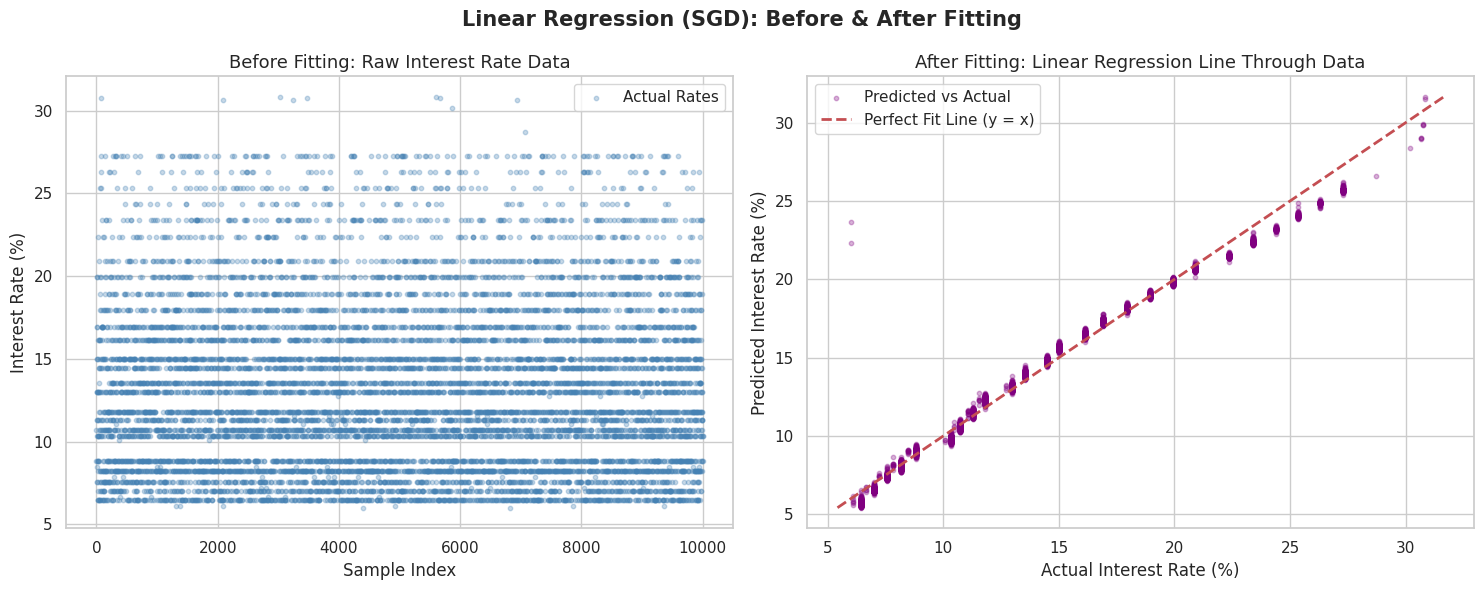

In [52]:
# 8. SCATTER PLOT — LINEAR REGRESSION: BEFORE & AFTER
#    Shows raw data scatter THEN the linear fit line through it
# ============================================================
sgd_preds = sgd_reg.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Before: raw data (no model, just the spread of actual values) ---
axes[0].scatter(range(len(y_test)), np.array(y_test),
                alpha=0.3, color='steelblue', s=10, label='Actual Rates')
axes[0].set_title('Before Fitting: Raw Interest Rate Data', fontsize=13)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].legend()

# --- After: actual vs predicted with the regression fit line ---
axes[1].scatter(np.array(y_test), sgd_preds,
                alpha=0.3, color='purple', s=10, label='Predicted vs Actual')
line_min = min(float(y_test.min()), float(sgd_preds.min()))
line_max = max(float(y_test.max()), float(sgd_preds.max()))
axes[1].plot([line_min, line_max], [line_min, line_max],
             'r--', lw=2, label='Perfect Fit Line (y = x)')
axes[1].set_title('After Fitting: Linear Regression Line Through Data', fontsize=13)
axes[1].set_xlabel('Actual Interest Rate (%)')
axes[1].set_ylabel('Predicted Interest Rate (%)')
axes[1].legend()

plt.suptitle('Linear Regression (SGD): Before & After Fitting', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('viz6_scatter_before_after_linear.png', dpi=150)
plt.show()


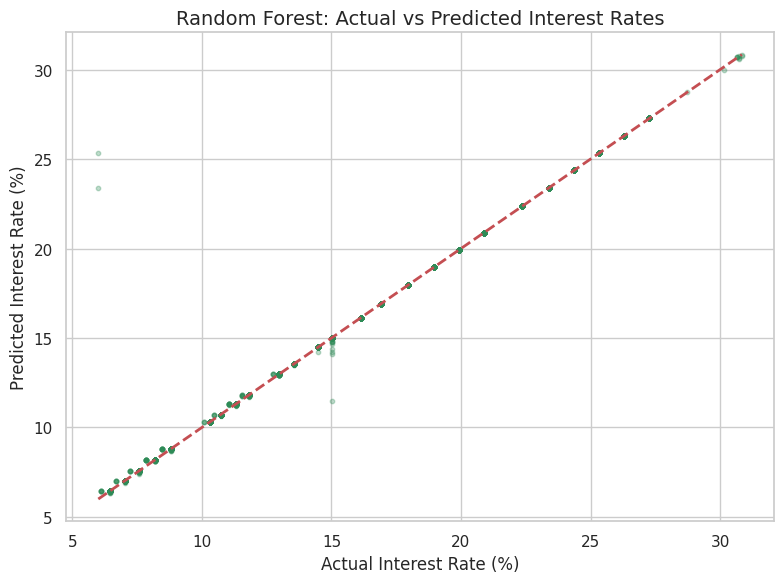

In [54]:

# ============================================================
rf_preds = results['Random Forest']['preds']
plt.figure(figsize=(8, 6))
plt.scatter(np.array(y_test), rf_preds, alpha=0.3, color='seagreen', s=10)
plt.plot([float(y_test.min()), float(y_test.max())],
         [float(y_test.min()), float(y_test.max())], 'r--', lw=2)
plt.title('Random Forest: Actual vs Predicted Interest Rates', fontsize=14)
plt.xlabel('Actual Interest Rate (%)')
plt.ylabel('Predicted Interest Rate (%)')
plt.tight_layout()
plt.savefig('viz7_rf_actual_vs_predicted.png', dpi=150)
plt.show()

In [55]:
# 10. SAVE BEST MODEL (lowest MSE)
# ============================================================
best_name = min(results, key=lambda k: results[k]['mse'])
print(f"\n✅ Best Model: {best_name}  (MSE: {results[best_name]['mse']:.4f})")

joblib.dump(rf_reg, 'best_loan_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Saved: best_loan_model.pkl and scaler.pkl")

# ============================================================


✅ Best Model: Random Forest  (MSE: 0.0698)
Saved: best_loan_model.pkl and scaler.pkl


In [56]:
# 11. SINGLE-ROW PREDICTION FROM TEST SET
#     Assignment requirement: predict on exactly one data point
# ============================================================
print("\n=== Single-Row Prediction Demo ===")

single_row        = X_test_raw.iloc[[0]]          # shape (1, n_features)
single_row_scaled = scaler.transform(single_row)
single_pred       = rf_reg.predict(single_row_scaled)[0]
single_actual     = float(y_test.iloc[0])

print(f"Input features:\n{single_row.to_string()}")
print(f"\nActual Interest Rate   : {single_actual:.2f}%")
print(f"Predicted Interest Rate: {single_pred:.2f}%")
print(f"Difference             : {abs(single_actual - single_pred):.2f}%")



=== Single-Row Prediction Demo ===
Input features:
       loan_amnt  term  installment  sub_grade  emp_length  home_ownership  annual_inc  verification_status  purpose    dti  delinq_2yrs  inq_last_6mths  open_acc  pub_rec  revol_bal  revol_util  total_acc  collections_12_mths_ex_med  application_type  tot_coll_amt  tot_cur_bal  open_acc_6m  open_act_il  open_il_12m  open_il_24m  mths_since_rcnt_il  total_bal_il  il_util  open_rv_12m  open_rv_24m  max_bal_bc  all_util  total_rev_hi_lim  inq_fi  total_cu_tl  inq_last_12m  acc_open_past_24mths  avg_cur_bal  bc_open_to_buy  bc_util  mo_sin_old_il_acct  mo_sin_old_rev_tl_op  mo_sin_rcnt_rev_tl_op  mo_sin_rcnt_tl  mort_acc  mths_since_recent_bc  mths_since_recent_inq  num_accts_ever_120_pd  num_actv_bc_tl  num_actv_rev_tl  num_bc_sats  num_bc_tl  num_il_tl  num_op_rev_tl  num_rev_accts  num_rev_tl_bal_gt_0  num_sats  num_tl_90g_dpd_24m  num_tl_op_past_12m  pct_tl_nvr_dlq  percent_bc_gt_75  pub_rec_bankruptcies  tot_hi_cred_lim  total_bal_e